In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import time
from tensorflow import keras

In [ ]:
!pip install --upgrade datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 18.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; pl

In [ ]:
from datasets import load_dataset

ds = load_dataset("MohamedRashad/midjourney-detailed-prompts")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/345M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/344M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3053 [00:00<?, ? examples/s]

In [ ]:
ds#['train']#['image_description'][0]

DatasetDict({
    train: Dataset({
        features: ['image', 'image_description', 'long_prompt', 'short_prompt'],
        num_rows: 3053
    })
})

In [ ]:
import tensorflow as tf
import numpy as np

# Model parameters
IMG_HEIGHT = 128
IMG_WIDTH = 128
IMG_CHANNELS = 3
BATCH_SIZE = 4
EMBEDDING_DIM = 256
TEXT_SEQ_LENGTH = 128

# Diffusion parameters
TIMESTEPS = 1000
MIN_BETA = 1e-4
MAX_BETA = 0.02
EPOCHS = 1
LEARNING_RATE = 1e-4

def linear_beta_schedule(timesteps, min_beta, max_beta):
    return tf.linspace(min_beta, max_beta, timesteps)

# Use TensorFlow tensors (float32)
betas = linear_beta_schedule(TIMESTEPS, MIN_BETA, MAX_BETA)
betas = tf.cast(betas, dtype=tf.float32)

alphas = 1.0 - betas
alphas_cumprod = tf.math.cumprod(alphas, axis=0)
alphas_cumprod_prev = tf.concat([tf.ones((1,), dtype=tf.float32), alphas_cumprod[:-1]], axis=0)

sqrt_recip_alphas = tf.sqrt(1.0 / alphas)
sqrt_alphas_cumprod = tf.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = tf.sqrt(1.0 - alphas_cumprod)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)


In [ ]:
def TextEncoder(vocab_size = 10000):
  inputs = keras.layers.Input(shape=(TEXT_SEQ_LENGTH,))
  x = keras.layers.Embedding(vocab_size, EMBEDDING_DIM)(inputs)
  x = keras.layers.LSTM(EMBEDDING_DIM)(x)
  x = keras.layers.Dense(EMBEDDING_DIM)(x)
  return keras.Model(inputs, x, name='Text_Encoder')

In [ ]:
def get_unet_model():
  # Text Input
  text_input = keras.layers.Input(shape=(EMBEDDING_DIM,), name='text_embedding')

  # Image and Time input
  image_input = keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), name='image_input')
  time_input = keras.layers.Input(shape=(), dtype=tf.int32, name='time_input')

  # Time Embedding
  time_embedding = keras.layers.Embedding(TIMESTEPS, EMBEDDING_DIM)(time_input)
  time_embedding = keras.layers.Dense(EMBEDDING_DIM, activation='swish')(time_embedding)
  time_embedding = keras.layers.Dense(EMBEDDING_DIM)(time_embedding)

  # Combine Text and Time Embedding
  combined_embedding = keras.layers.Concatenate()([text_input, time_embedding])
  combined_embedding = keras.layers.Dense(EMBEDDING_DIM*4)(combined_embedding)
  combined_embedding = keras.layers.Dense(IMG_HEIGHT*IMG_WIDTH)(combined_embedding)
  combined_embedding = keras.layers.Reshape((IMG_HEIGHT, IMG_WIDTH, 1))(combined_embedding)

  # Downsample Input Image
  x = keras.layers.Conv2D(filters=64, kernel_size=3, padding = 'same')(image_input)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Activation('swish')(x)

  # Add Conditioning
  x = keras.layers.Concatenate()([x, combined_embedding])

  # U-net Architecture
  # Downsampling
  down1 = keras.layers.Conv2D(filters=128, kernel_size=3, strides=2, padding = 'same')(x)
  down1 = keras.layers.BatchNormalization()(down1)
  down1 = keras.layers.Activation('swish')(down1)

  down2 = keras.layers.Conv2D(filters=256, kernel_size=3, strides=2, padding='same')(down1)
  down2 = keras.layers.BatchNormalization()(down2)
  down2 = keras.layers.Activation('swish')(down2)

  # Bottleneck
  bottleneck = keras.layers.Conv2D(filters=512, kernel_size=3, padding='same')(down2)
  bottleneck = keras.layers.BatchNormalization()(bottleneck)
  bottleneck = keras.layers.Activation('swish')(bottleneck)

  # Upsampling
  up1 = keras.layers.UpSampling2D(size=2)(bottleneck)
  up1 = keras.layers.Conv2D(filters=256, kernel_size=3, padding='same')(up1)
  up1 = keras.layers.BatchNormalization()(up1)
  up1 = keras.layers.Activation('swish')(up1)
  up1 = keras.layers.Concatenate()([up1, down1])

  up2 = keras.layers.UpSampling2D(size=2)(up1)
  up2 = keras.layers.Conv2D(filters=128, kernel_size=3, padding='same')(up2)
  up2 = keras.layers.BatchNormalization()(up2)
  up2 = keras.layers.Activation('swish')(up2)
  up2 = keras.layers.Concatenate()([up2, x])

  #output
  output = keras.layers.Conv2D(filters=IMG_CHANNELS, kernel_size=3, padding='same')(up2)
  return keras.Model([image_input, time_input, text_input], output, name='UNet')

In [ ]:
from math import sqrt
class DiffusionModel(keras.Model):
  def __init__(self):
    super().__init__()
    self.text_encoder = TextEncoder()
    self.unet = get_unet_model()
    self.timesteps = TIMESTEPS
    self.betas = betas
    self.alphas = alphas
    self.alphas_cumprod = alphas_cumprod
    self.sqrt_alphas_cumprod = sqrt_alphas_cumprod
    self.sqrt_one_minus_alphas_cumprod = sqrt_one_minus_alphas_cumprod
    self.alphas_cumprod_prev = alphas_cumprod_prev
    self.posterior_variance = posterior_variance

  def compile(self, **kwargs):
    super().compile(**kwargs)
    self.noise_loss_tracker = keras.metrics.Mean(name='noise_loss')

  @property
  def metrics(self):
    return [self.noise_loss_tracker]

  def sample_timesteps(self, n):
    return tf.random.uniform(shape=[n], minval=0, maxval=self.timesteps, dtype=tf.int32)

  def add_noise(self, x, t, noise=None):
    if noise is None:
      noise =  tf.random.normal(shape=x.shape)

    sqrt_alpha = tf.reshape(tf.gather(self.sqrt_alphas_cumprod, t), [-1, 1, 1, 1])
    sqrt_one_minus_alpha = tf.reshape(tf.gather(self.sqrt_one_minus_alphas_cumprod, t), [-1, 1, 1, 1])
    return sqrt_alpha * x + sqrt_one_minus_alpha * noise, noise

  def train_step(self, data):
    image, text = data

    batch_size = tf.shape(image)[0]
    t = self.sample_timesteps(batch_size)

    text_embedding = self.text_encoder(text)
    noise = tf.random.normal(shape=image.shape)
    noisy_image, noise = self.add_noise(image, t)

    with tf.GradientTape() as tape:
      pred_noise = self.unet([noisy_image, t, text_embedding])

      loss = keras.losses.mse(noise, pred_noise)

    gradients = tape.gradient(loss, self.trainable_weights)
    self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))

    self.noise_loss_tracker.update_state(loss)

    return {m.name: m.result() for m in self.metrics}

  def sample(self, text_embedding, n=1, steps=None):
    if steps is None:
      steps = self.timesteps

    x = tf.random.normal(shape=(n, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    imgs = []
    for t in reversed(range(0,steps)):
      print(f"Sampling timestep {t:4d}", end="\r")
      timestep = tf.constant([t], dtype=tf.int32)
      pred_noise = self.unet([x, timestep, text_embedding])

      alpha = tf.reshape(self.alphas[t], [1, 1, 1, 1])
      alpha_cumprod = tf.reshape(self.alphas_cumprod[t], [1, 1, 1, 1])
      alpha_cumprod_prev = tf.reshape(self.alphas_cumprod_prev[t], [1, 1, 1, 1])

      pred_x0 = (x - tf.sqrt(1 - alpha_cumprod) * pred_noise) / tf.sqrt(alpha_cumprod)
      dir_xt = tf.sqrt(1 - alpha_cumprod_prev) * pred_noise

      x = tf.sqrt(alpha_cumprod_prev) * pred_x0 + dir_xt


    return x

In [ ]:
diffusion_model = DiffusionModel()
diffusion_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))

def train_model(model, dataset, epochs):
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        for batch_idx, (image, text) in enumerate(dataset):
          loss = model.train_step((image, text))
          if batch_idx % 10 == 0:
            print(f"Batch {batch_idx}, Loss: {loss['noise_loss'].numpy():.4f}")

        # Sampling at end of epoch
        sample_text = ["a red Car"]
        sequences = tokenizer.texts_to_sequences(sample_text)
        padded = pad_sequences(sequences, maxlen=TEXT_SEQ_LENGTH, padding='post', truncating='post')
        padded = tf.convert_to_tensor(padded, dtype=tf.int32)
        print(padded.shape)

        text_embedding = model.text_encoder(padded)

        generated = model.sample(text_embedding, n=1)

        # Convert to numpy if needed
        img = generated[0].numpy()
        img = (img - img.min()) / (img.max() - img.min())  # Normalize for display

        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Epoch {epoch+1}")
        plt.show()


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(["a red car", "a blue truck", "a yellow bike", "a green bus"])


In [ ]:
# def create_dummy_dataset(batch_size=4, steps=50):
#     for _ in range(steps):
#         images = np.random.randn(batch_size, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS).astype(np.float32)
#         texts = np.random.choice(["a red car", "a blue truck", "a yellow bike"], size=batch_size)
#         yield images, texts
def create_dummy_dataset(tokenizer, batch_size=1, steps=50):
    for _ in range(steps):
        images = np.random.randn(batch_size, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS).astype(np.float32)
        texts = np.random.choice(["a red car", "a blue truck", "a green bus"], size=batch_size)

        # Tokenize and pad
        sequences = tokenizer.texts_to_sequences(texts)
        padded = pad_sequences(sequences, maxlen=TEXT_SEQ_LENGTH, padding='post', truncating='post')
        padded = tf.convert_to_tensor(padded, dtype=tf.int32)

        yield images, padded

dummy_dataset = tf.data.Dataset.from_generator(
    lambda: create_dummy_dataset(tokenizer, batch_size=1, steps=10),
    output_signature=(
        tf.TensorSpec(shape=(1, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=tf.float32),
        tf.TensorSpec(shape=(1, TEXT_SEQ_LENGTH), dtype=tf.int32)
    )
)

In [ ]:
diffusion_model = DiffusionModel()
diffusion_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))



Epoch 1/1


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:774: UserWarning: Gradients do not exist for variables ['embedding_98/embeddings', 'lstm_49/lstm_cell/kernel', 'lstm_49/lstm_cell/recurrent_kernel', 'lstm_49/lstm_cell/bias', 'dense_245/kernel', 'dense_245/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Batch 0, Loss: 1.0008


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:774: UserWarning: Gradients do not exist for variables ['embedding_98/embeddings', 'lstm_49/lstm_cell/kernel', 'lstm_49/lstm_cell/recurrent_kernel', 'lstm_49/lstm_cell/bias', 'dense_245/kernel', 'dense_245/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:774: UserWarning: Gradients do not exist for variables ['embedding_98/embeddings', 'lstm_49/lstm_cell/kernel', 'lstm_49/lstm_cell/recurrent_kernel', 'lstm_49/lstm_cell/bias', 'dense_245/kernel', 'dense_245/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:774: UserWarning: Gradients do not exist for variables ['embedding_98/embeddings', 'lstm_49/lstm_cell/ker

(1, 128)


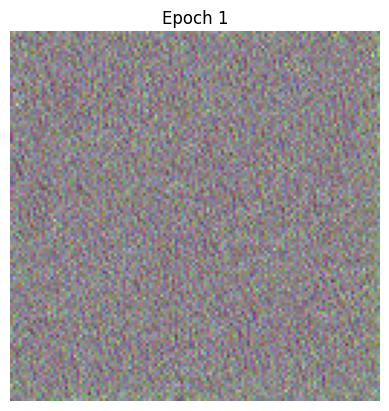

In [ ]:
# train_model(diffusion_model, dummy_dataset, epochs=1)

In [ ]:
def dataset_generator(dataset, tokenizer, batch_size=2):
    total = len(dataset)
    idx = 0

    while idx < total:
        batch_images = []
        batch_texts = []

        for _ in range(batch_size):
            if idx >= total:
                break

            item = dataset[idx]
            idx += 1

            img = np.array(item['image'].resize((IMG_WIDTH, IMG_HEIGHT)))  # resize image
            if IMG_CHANNELS == 1:
                # convert to grayscale if needed
                img = img.mean(axis=2, keepdims=True).astype(np.uint8)
            else:
                img = img.astype(np.uint8)

            # Normalize image to float32 [0,1]
            img = img / 255.0

            batch_images.append(img)

            # Tokenize text (e.g., short_prompt)
            text = item['short_prompt']
            seq = tokenizer.texts_to_sequences([text])[0]

            # Pad/truncate to fixed length
            if len(seq) < TEXT_SEQ_LENGTH:
                seq = seq + [0] * (TEXT_SEQ_LENGTH - len(seq))
            else:
                seq = seq[:TEXT_SEQ_LENGTH]

            batch_texts.append(seq)

        # Convert batch to numpy arrays/tensors
        batch_images = np.array(batch_images, dtype=np.float32)
        batch_texts = np.array(batch_texts, dtype=np.int32)

        yield batch_images, batch_texts


In [ ]:
dummy_dataset = tf.data.Dataset.from_generator(
    lambda: dataset_generator(ds['train'], tokenizer, batch_size=32),
    output_signature=(
        tf.TensorSpec(shape=(None, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=tf.float32),
        tf.TensorSpec(shape=(None, TEXT_SEQ_LENGTH), dtype=tf.int32)
    )
)


Epoch 1/1


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:774: UserWarning: Gradients do not exist for variables ['embedding/embeddings', 'lstm/lstm_cell/kernel', 'lstm/lstm_cell/recurrent_kernel', 'lstm/lstm_cell/bias', 'dense/kernel', 'dense/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Batch 0, Loss: 0.9994
Batch 10, Loss: 0.9624
Batch 20, Loss: 0.9265
Batch 30, Loss: 0.8898
Batch 40, Loss: 0.8513
Batch 50, Loss: 0.8134
Batch 60, Loss: 0.7744
Batch 70, Loss: 0.7387
Batch 80, Loss: 0.7028
Batch 90, Loss: 0.6731
(1, 128)


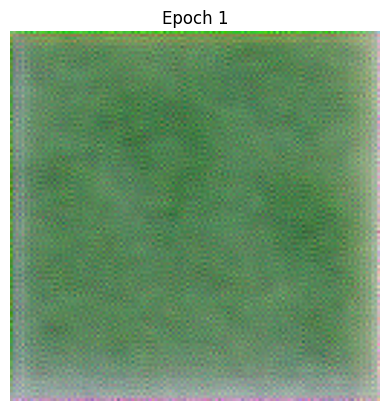

In [ ]:
train_model(diffusion_model, dummy_dataset, epochs=1)

In [ ]:
len(ds)

1